# Pairs Trading & Statistical Arbitrage

**CQF-Level Example**: Mean-reversion strategies:
- Cointegration testing (Engle-Granger)
- Spread construction and z-score
- Half-life of mean reversion
- Pairs selection using distance method
- Strategy backtesting

**Connectors Used:**
- `qj.eod` - Historical prices

**API:** https://api.quantjourney.cloud

## Preview Chart

![29_pairs_trading_stat_arb](../outputs/candidates/29_pairs_trading_stat_arb.png)

In [2]:
# Setup
import sys
sys.path.insert(0, '..')

from quantjourney.sdk import QuantJourneyAPI
import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "png"

import os
API_KEY = os.environ.get("QJ_API_KEY", "qj_...")
qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")


✓ Connected to QuantJourney API


## 1. Fetch Sector Stocks for Pairs Candidates

In [3]:
# Technology sector candidates
symbols = ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN', 'NVDA', 'CRM', 'ADBE', 'INTC', 'AMD']

prices = {}
for symbol in symbols:
    try:
        response = qj.eod.get_historical_prices(
            symbol=symbol,
            start_date='2021-01-01',
            end_date='2024-12-31',
            frequency='1d'
        )
        data = response.get('value', response) if isinstance(response, dict) else response
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            prices[symbol] = df['adjusted_close' if 'adjusted_close' in df.columns else 'close']
            print(f"✓ {symbol}")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

# Fallback
if len(prices) < 5:
    print("\nGenerating synthetic data...")
    dates = pd.date_range(start='2021-01-01', end='2024-12-31', freq='B')
    np.random.seed(42)
    common_factor = np.cumsum(0.001 + 0.02 * np.random.randn(len(dates)))
    for i, sym in enumerate(symbols):
        idio = np.cumsum(0.001 * np.random.randn(len(dates)))
        prices[sym] = pd.Series(100 * np.exp(common_factor + idio), index=dates)


✓ AAPL
✓ MSFT
✓ GOOGL
✓ META
✓ AMZN
✓ NVDA
✓ CRM
✓ ADBE
✓ INTC
✓ AMD


In [4]:
# Create price matrix
prices_df = pd.DataFrame(prices).dropna()
returns_df = prices_df.pct_change().dropna()

# Normalize for comparison
norm_prices = prices_df / prices_df.iloc[0] * 100

print(f"Period: {prices_df.index.min().date()} to {prices_df.index.max().date()}")
print(f"Stocks: {len(prices_df.columns)}")
print(f"Days: {len(prices_df)}")


Period: 2021-01-04 to 2024-12-31
Stocks: 10
Days: 1005


## 2. Distance Method: Find Similar Price Series

In [5]:
# Calculate SSD (Sum of Squared Differences) for all pairs
from itertools import combinations

pair_distances = []
for s1, s2 in combinations(norm_prices.columns, 2):
    ssd = np.sum((norm_prices[s1] - norm_prices[s2])**2)
    corr = returns_df[s1].corr(returns_df[s2])
    pair_distances.append({
        'Pair': f"{s1}/{s2}",
        'Stock1': s1,
        'Stock2': s2,
        'SSD': ssd,
        'Correlation': corr
    })

distance_df = pd.DataFrame(pair_distances).sort_values('SSD')
print("Top 10 Pairs by Distance Method (lowest SSD = most similar):")
print(distance_df.head(10).to_string(index=False))


Top 10 Pairs by Distance Method (lowest SSD = most similar):
      Pair Stock1 Stock2           SSD  Correlation
  AMZN/CRM   AMZN    CRM 202579.908142     0.549186
MSFT/GOOGL   MSFT  GOOGL 219500.647893     0.698807
  CRM/ADBE    CRM   ADBE 266136.736795     0.606306
 AMZN/ADBE   AMZN   ADBE 303594.959120     0.555946
 AAPL/MSFT   AAPL   MSFT 561192.134940     0.680685
AAPL/GOOGL   AAPL  GOOGL 687908.671894     0.606136
  AAPL/AMD   AAPL    AMD 753261.410804     0.523529
 ADBE/INTC   ADBE   INTC 768715.148425     0.365220
 AMZN/INTC   AMZN   INTC 859168.837000     0.413633
  META/AMD   META    AMD 918991.973936     0.478773


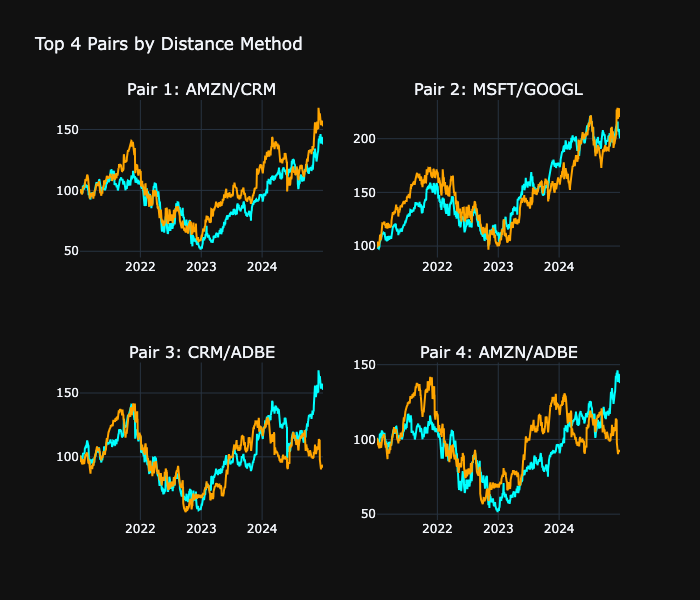

In [6]:
# Visualize top pairs
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    f"Pair 1: {distance_df.iloc[0]['Pair']}",
    f"Pair 2: {distance_df.iloc[1]['Pair']}",
    f"Pair 3: {distance_df.iloc[2]['Pair']}",
    f"Pair 4: {distance_df.iloc[3]['Pair']}"
])

for i, (_, row) in enumerate(distance_df.head(4).iterrows()):
    r, c = divmod(i, 2)
    fig.add_trace(
        go.Scatter(x=norm_prices.index, y=norm_prices[row['Stock1']],
                   name=row['Stock1'], line=dict(color='cyan')),
        row=r+1, col=c+1
    )
    fig.add_trace(
        go.Scatter(x=norm_prices.index, y=norm_prices[row['Stock2']],
                   name=row['Stock2'], line=dict(color='orange')),
        row=r+1, col=c+1
    )

fig.update_layout(height=600, template='plotly_dark', showlegend=False,
                  title='Top 4 Pairs by Distance Method')
fig.show()


## 3. Cointegration Testing (Engle-Granger)

In [7]:
def adf_test(series):
    """Augmented Dickey-Fuller test using numpy"""
    n = len(series)
    y = series.values
    
    # First differences
    dy = np.diff(y)
    y_lag = y[:-1]
    
    # OLS: dy = alpha + gamma*y_lag + epsilon
    X = np.column_stack([np.ones(len(y_lag)), y_lag])
    beta = np.linalg.lstsq(X, dy, rcond=None)[0]
    
    # Calculate residuals and t-stat
    resid = dy - X @ beta
    mse = np.sum(resid**2) / (len(resid) - 2)
    se = np.sqrt(mse * np.linalg.inv(X.T @ X).diagonal())
    t_stat = beta[1] / se[1]
    
    # Critical values (5%)
    critical_5pct = -2.86
    
    return t_stat, critical_5pct, t_stat < critical_5pct

def engle_granger_test(y1, y2):
    """Engle-Granger cointegration test"""
    # Step 1: OLS regression y1 = alpha + beta*y2 + epsilon
    X = np.column_stack([np.ones(len(y2)), y2.values])
    beta = np.linalg.lstsq(X, y1.values, rcond=None)[0]
    hedge_ratio = beta[1]
    
    # Step 2: Calculate residuals (spread)
    spread = y1 - hedge_ratio * y2
    
    # Step 3: ADF test on residuals
    adf_stat, critical, is_coint = adf_test(spread)
    
    return {
        'hedge_ratio': hedge_ratio,
        'spread': spread,
        'adf_stat': adf_stat,
        'critical_5pct': critical,
        'is_cointegrated': is_coint
    }


In [8]:
# Test all pairs for cointegration
coint_results = []

for s1, s2 in combinations(prices_df.columns, 2):
    result = engle_granger_test(prices_df[s1], prices_df[s2])
    coint_results.append({
        'Pair': f"{s1}/{s2}",
        'Stock1': s1,
        'Stock2': s2,
        'Hedge Ratio': result['hedge_ratio'],
        'ADF Stat': result['adf_stat'],
        'Critical 5%': result['critical_5pct'],
        'Cointegrated': result['is_cointegrated']
    })

coint_df = pd.DataFrame(coint_results).sort_values('ADF Stat')

print("Cointegration Test Results (sorted by ADF statistic):")
print(coint_df[['Pair', 'Hedge Ratio', 'ADF Stat', 'Critical 5%', 'Cointegrated']].head(10).to_string(index=False))

coint_pairs = coint_df[coint_df['Cointegrated']]
print(f"\n{len(coint_pairs)} cointegrated pairs found at 5% level")


Cointegration Test Results (sorted by ADF statistic):
      Pair  Hedge Ratio  ADF Stat  Critical 5%  Cointegrated
GOOGL/META     0.168971 -3.398069        -2.86          True
GOOGL/AMZN     0.642755 -3.368745        -2.86          True
  AMZN/CRM     0.579887 -3.200650        -2.86          True
 GOOGL/CRM     0.413724 -3.099367        -2.86          True
  META/CRM     2.399409 -3.022496        -2.86          True
GOOGL/NVDA     0.542699 -2.954556        -2.86          True
 AAPL/NVDA     0.704780 -2.848411        -2.86         False
  MSFT/AMD     1.884607 -2.819579        -2.86         False
 MSFT/NVDA     1.614992 -2.780381        -2.86         False
 MSFT/META     0.454060 -2.596549        -2.86         False

6 cointegrated pairs found at 5% level


## 4. Select Best Pair & Analyze Spread

In [9]:
# Select best pair (most negative ADF or first cointegrated)
if len(coint_pairs) > 0:
    best_pair = coint_pairs.iloc[0]
else:
    best_pair = coint_df.iloc[0]
    
stock1, stock2 = best_pair['Stock1'], best_pair['Stock2']
hedge_ratio = best_pair['Hedge Ratio']

print(f"Selected Pair: {stock1}/{stock2}")
print(f"Hedge Ratio: {hedge_ratio:.4f}")
print(f"ADF Statistic: {best_pair['ADF Stat']:.4f}")
print(f"Cointegrated: {best_pair['Cointegrated']}")


Selected Pair: GOOGL/META
Hedge Ratio: 0.1690
ADF Statistic: -3.3981
Cointegrated: True


In [10]:
# Calculate spread
spread = prices_df[stock1] - hedge_ratio * prices_df[stock2]
spread_mean = spread.mean()
spread_std = spread.std()

# Z-score
zscore = (spread - spread_mean) / spread_std

print(f"\nSpread Statistics:")
print(f"  Mean: {spread_mean:.2f}")
print(f"  Std:  {spread_std:.2f}")
print(f"  Current Z-score: {zscore.iloc[-1]:.2f}")



Spread Statistics:
  Mean: 76.06
  Std:  12.15
  Current Z-score: 1.14


In [11]:
# Calculate half-life of mean reversion
def half_life(spread):
    """Ornstein-Uhlenbeck half-life estimation"""
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()
    
    # OLS: spread_diff = alpha + theta*spread_lag
    X = np.column_stack([np.ones(len(spread_lag)), spread_lag.values])
    beta = np.linalg.lstsq(X, spread_diff.values, rcond=None)[0]
    theta = beta[1]
    
    if theta >= 0:
        return np.inf
    return -np.log(2) / theta

hl = half_life(spread)
print(f"Half-life of mean reversion: {hl:.1f} days")


Half-life of mean reversion: 37.9 days


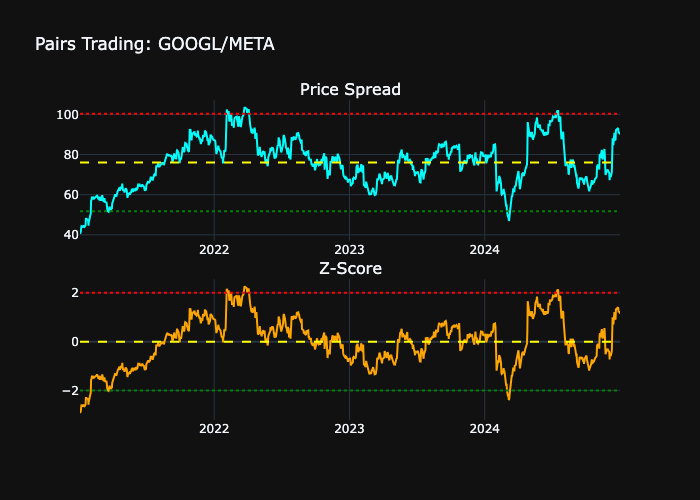

In [12]:
# Spread and z-score chart
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['Price Spread', 'Z-Score'],
    vertical_spacing=0.12
)

# Spread
fig.add_trace(
    go.Scatter(x=spread.index, y=spread, mode='lines', name='Spread',
               line=dict(color='cyan')),
    row=1, col=1
)
fig.add_hline(y=spread_mean, line_dash="dash", line_color="yellow", row=1, col=1)
fig.add_hline(y=spread_mean + 2*spread_std, line_dash="dot", line_color="red", row=1, col=1)
fig.add_hline(y=spread_mean - 2*spread_std, line_dash="dot", line_color="green", row=1, col=1)

# Z-score
fig.add_trace(
    go.Scatter(x=zscore.index, y=zscore, mode='lines', name='Z-Score',
               line=dict(color='orange')),
    row=2, col=1
)
fig.add_hline(y=0, line_dash="dash", line_color="yellow", row=2, col=1)
fig.add_hline(y=2, line_dash="dot", line_color="red", row=2, col=1)
fig.add_hline(y=-2, line_dash="dot", line_color="green", row=2, col=1)

fig.update_layout(
    title=f'Pairs Trading: {stock1}/{stock2}',
    template='plotly_dark',
    height=500,
    showlegend=False
)
fig.show()


## 5. Pairs Trading Strategy Backtest

In [13]:
# Strategy parameters
entry_z = 2.0    # Enter when |z| > 2
exit_z = 0.0     # Exit when z crosses 0
stop_z = 3.5     # Stop loss at |z| > 3.5

# Generate signals
position = pd.Series(0, index=zscore.index)
in_trade = False
trade_direction = 0

for i in range(1, len(zscore)):
    z = zscore.iloc[i]
    
    if not in_trade:
        if z > entry_z:  # Short spread (short stock1, long stock2)
            position.iloc[i] = -1
            in_trade = True
            trade_direction = -1
        elif z < -entry_z:  # Long spread (long stock1, short stock2)
            position.iloc[i] = 1
            in_trade = True
            trade_direction = 1
    else:
        # Check exit conditions
        if trade_direction == 1 and z >= exit_z:  # Exit long
            position.iloc[i] = 0
            in_trade = False
        elif trade_direction == -1 and z <= exit_z:  # Exit short
            position.iloc[i] = 0
            in_trade = False
        elif abs(z) > stop_z:  # Stop loss
            position.iloc[i] = 0
            in_trade = False
        else:
            position.iloc[i] = trade_direction

# Forward fill positions
position = position.replace(0, np.nan).ffill().fillna(0)

print(f"Total trading days: {len(position)}")
print(f"Days in long position: {(position == 1).sum()}")
print(f"Days in short position: {(position == -1).sum()}")
print(f"Days flat: {(position == 0).sum()}")


Total trading days: 1005
Days in long position: 365
Days in short position: 639
Days flat: 1


In [14]:
# Calculate strategy returns
spread_returns = spread.pct_change()
strategy_returns = position.shift(1) * spread_returns
strategy_returns = strategy_returns.fillna(0)

# Cumulative returns
strategy_cumulative = (1 + strategy_returns).cumprod() - 1
spread_cumulative = (1 + spread_returns.fillna(0)).cumprod() - 1

# Performance metrics
total_return = strategy_cumulative.iloc[-1]
ann_return = (1 + total_return) ** (252 / len(strategy_returns)) - 1
ann_vol = strategy_returns.std() * np.sqrt(252)
sharpe = ann_return / ann_vol if ann_vol > 0 else 0

# Drawdown
cumulative = (1 + strategy_returns).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_dd = drawdown.min()

print(f"\nStrategy Performance:")
print(f"  Total Return: {total_return*100:.1f}%")
print(f"  Annual Return: {ann_return*100:.1f}%")
print(f"  Annual Volatility: {ann_vol*100:.1f}%")
print(f"  Sharpe Ratio: {sharpe:.2f}")
print(f"  Max Drawdown: {max_dd*100:.1f}%")



Strategy Performance:
  Total Return: 572.8%
  Annual Return: 61.3%
  Annual Volatility: 43.9%
  Sharpe Ratio: 1.40
  Max Drawdown: -38.9%


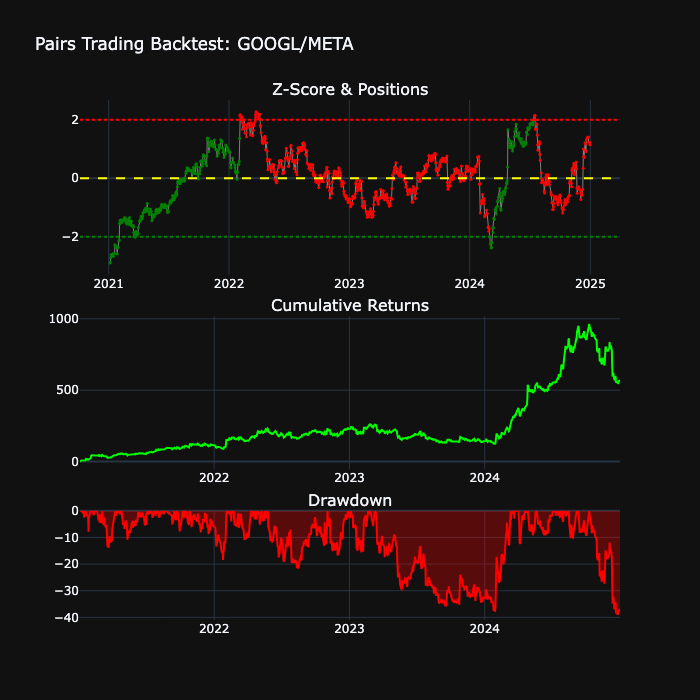

In [15]:
# Strategy chart
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=['Z-Score & Positions', 'Cumulative Returns', 'Drawdown'],
    row_heights=[0.4, 0.35, 0.25],
    vertical_spacing=0.08
)

# Z-score with positions
fig.add_trace(
    go.Scatter(x=zscore.index, y=zscore, mode='lines', name='Z-Score',
               line=dict(color='gray', width=1)),
    row=1, col=1
)

# Highlight positions
long_idx = position[position == 1].index
short_idx = position[position == -1].index

fig.add_trace(
    go.Scatter(x=long_idx, y=zscore[long_idx], mode='markers',
               name='Long', marker=dict(color='green', size=3)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=short_idx, y=zscore[short_idx], mode='markers',
               name='Short', marker=dict(color='red', size=3)),
    row=1, col=1
)

fig.add_hline(y=entry_z, line_dash="dot", line_color="red", row=1, col=1)
fig.add_hline(y=-entry_z, line_dash="dot", line_color="green", row=1, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="yellow", row=1, col=1)

# Cumulative returns
fig.add_trace(
    go.Scatter(x=strategy_cumulative.index, y=strategy_cumulative * 100,
               mode='lines', name='Strategy', line=dict(color='lime')),
    row=2, col=1
)

# Drawdown
fig.add_trace(
    go.Scatter(x=drawdown.index, y=drawdown * 100, mode='lines',
               name='Drawdown', fill='tozeroy',
               line=dict(color='red'), fillcolor='rgba(255,0,0,0.3)'),
    row=3, col=1
)

fig.update_layout(
    title=f'Pairs Trading Backtest: {stock1}/{stock2}',
    template='plotly_dark',
    height=700,
    showlegend=False
)
fig.show()


## 6. Trade Analysis

In [16]:
# Identify individual trades
position_change = position.diff().fillna(0)
entries = position_change[position_change != 0].index

trades = []
trade_start = None
trade_direction = 0

for date in entries:
    new_pos = position[date]
    if trade_start is None and new_pos != 0:
        trade_start = date
        trade_direction = new_pos
    elif trade_start is not None and new_pos == 0:
        # Trade closed
        entry_spread = spread[trade_start]
        exit_spread = spread[date]
        pnl = trade_direction * (exit_spread - entry_spread) / entry_spread
        duration = (date - trade_start).days
        trades.append({
            'Entry': trade_start.date(),
            'Exit': date.date(),
            'Direction': 'Long' if trade_direction == 1 else 'Short',
            'Duration': duration,
            'PnL %': pnl * 100
        })
        trade_start = None

trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    print(f"\nTrade Analysis:")
    print(f"  Total Trades: {len(trades_df)}")
    print(f"  Winning Trades: {(trades_df['PnL %'] > 0).sum()}")
    print(f"  Win Rate: {(trades_df['PnL %'] > 0).mean()*100:.1f}%")
    print(f"  Avg PnL: {trades_df['PnL %'].mean():.2f}%")
    print(f"  Avg Duration: {trades_df['Duration'].mean():.1f} days")
    print(f"\nRecent Trades:")
    print(trades_df.tail(10).to_string(index=False))
else:
    print("No completed trades in backtest period")


No completed trades in backtest period


## 7. Out-of-Sample Validation

In [17]:
# Rolling cointegration test
window = 252  # 1 year
rolling_coint = []

for i in range(window, len(prices_df), 20):  # Check every 20 days
    y1 = prices_df[stock1].iloc[i-window:i]
    y2 = prices_df[stock2].iloc[i-window:i]
    result = engle_granger_test(y1, y2)
    rolling_coint.append({
        'date': prices_df.index[i],
        'adf_stat': result['adf_stat'],
        'hedge_ratio': result['hedge_ratio'],
        'cointegrated': result['is_cointegrated']
    })

rolling_coint_df = pd.DataFrame(rolling_coint).set_index('date')

print(f"\nRolling Cointegration Analysis:")
print(f"  % of windows cointegrated: {rolling_coint_df['cointegrated'].mean()*100:.1f}%")
print(f"  Hedge ratio range: [{rolling_coint_df['hedge_ratio'].min():.2f}, {rolling_coint_df['hedge_ratio'].max():.2f}]")



Rolling Cointegration Analysis:
  % of windows cointegrated: 7.9%
  Hedge ratio range: [0.03, 0.44]


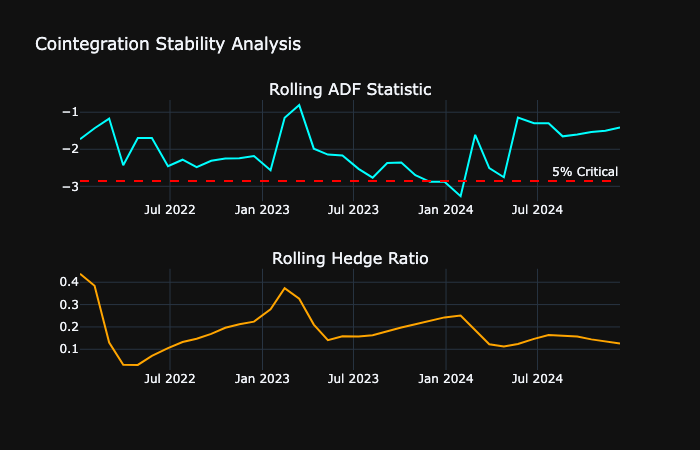

In [18]:
# Rolling cointegration chart
fig = make_subplots(rows=2, cols=1, subplot_titles=['Rolling ADF Statistic', 'Rolling Hedge Ratio'])

fig.add_trace(
    go.Scatter(x=rolling_coint_df.index, y=rolling_coint_df['adf_stat'],
               mode='lines', name='ADF Stat', line=dict(color='cyan')),
    row=1, col=1
)
fig.add_hline(y=-2.86, line_dash="dash", line_color="red", row=1, col=1,
              annotation_text="5% Critical")

fig.add_trace(
    go.Scatter(x=rolling_coint_df.index, y=rolling_coint_df['hedge_ratio'],
               mode='lines', name='Hedge Ratio', line=dict(color='orange')),
    row=2, col=1
)

fig.update_layout(
    title='Cointegration Stability Analysis',
    template='plotly_dark',
    height=450,
    showlegend=False
)
fig.show()


## 8. Summary

In [ ]:
print("="*70)
print("PAIRS TRADING ANALYSIS SUMMARY")
print("="*70)

print(f"\n1. PAIR SELECTION")
print(f"   Selected: {stock1}/{stock2}")
print(f"   Method: Engle-Granger Cointegration")

print(f"\n2. SPREAD CHARACTERISTICS")
print(f"   Hedge Ratio: {hedge_ratio:.4f}")
print(f"   Half-life: {hl:.1f} days")
print(f"   ADF Stat: {best_pair['ADF Stat']:.4f}")
print(f"   Cointegrated: {best_pair['Cointegrated']}")

print(f"\n3. STRATEGY PARAMETERS")
print(f"   Entry Z-score: ±{entry_z}")
print(f"   Exit Z-score: {exit_z}")
print(f"   Stop Z-score: ±{stop_z}")

print(f"\n4. BACKTEST RESULTS")
print(f"   Total Return: {total_return*100:.1f}%")
print(f"   Sharpe Ratio: {sharpe:.2f}")
print(f"   Max Drawdown: {max_dd*100:.1f}%")
if len(trades_df) > 0:
    print(f"   Win Rate: {(trades_df['PnL %'] > 0).mean()*100:.1f}%")

print(f"\n5. STABILITY")
print(f"   Rolling Cointegration: {rolling_coint_df['cointegrated'].mean()*100:.1f}% of periods")

print("\n" + "="*70)


PAIRS TRADING ANALYSIS SUMMARY

1. PAIR SELECTION
   Selected: GOOGL/META
   Method: Engle-Granger Cointegration

2. SPREAD CHARACTERISTICS
   Hedge Ratio: 0.1690
   Half-life: 37.9 days
   ADF Stat: -3.3981
   Cointegrated: True

3. STRATEGY PARAMETERS
   Entry Z-score: ±2.0
   Exit Z-score: 0.0
   Stop Z-score: ±3.5

4. BACKTEST RESULTS
   Total Return: 572.8%
   Sharpe Ratio: 1.40
   Max Drawdown: -38.9%

5. STABILITY
   Rolling Cointegration: 7.9% of periods



: 

## Summary

This CQF-level example covered:

1. **Distance Method**: Finding similar price series
2. **Cointegration Testing**: Engle-Granger methodology
3. **Spread Analysis**: Z-score and half-life
4. **Strategy Backtest**: Entry/exit rules based on z-score
5. **Trade Analysis**: Individual trade statistics
6. **Stability Testing**: Rolling cointegration windows

**Key Considerations for Funds**:
- Transaction costs impact (not included)
- Execution slippage
- Cointegration breakdown risk
- Position sizing and leverage